In [1]:
import matplotlib.pyplot as plt
from utils import load_most_recent_file
import os
import pandas as pd
test = False

script_dir = os.getcwd()
if test:
    outputs_dir = os.path.join(script_dir, 'test/outputs')
else:
    outputs_dir = os.path.join(script_dir, 'outputs')

pattern = '_all-institutions_all-authors-datasets-PUBLISHED.csv'
authors = load_most_recent_file(outputs_dir, pattern)

pattern = '_all-institutions_all-datasets-authors-PUBLISHED.csv'
datasets = load_most_recent_file(outputs_dir, pattern)

affiliation_mapping = {
    'Baylor': 'Baylor U',
    'HSC Fort Worth': 'UNT-HSC',
    'Houston': 'U Houston',
    'TAMU International': 'TAMIU',
    'Texas State': 'Texas State U',
    'Texas Tech': 'Texas Tech U',
    "Texas Women's University": "Texas Woman's U",
    'UT San Antonio Health': 'UTHSCSA',
    'UT Southwestern Medical': 'UT Southwestern'
}

datasets['institution_standardized'] = datasets['institution']
datasets['institution_standardized'] = datasets['institution_standardized'].replace(affiliation_mapping)

authors['institution_standardized'] = authors['institution']
authors['institution_standardized'] = authors['institution_standardized'].replace(affiliation_mapping)

The most recent file '20260601_all-institutions_all-authors-datasets-PUBLISHED.csv' has been loaded successfully.

The most recent file '20260601_all-institutions_all-datasets-authors-PUBLISHED.csv' has been loaded successfully.



institution_standardized
UT Austin          72.807822
SMU                11.320755
Texas Tech U        7.539683
TAMIU               7.407407
Baylor U            5.329154
TAMU                4.459309
UT Southwestern     3.007519
U Houston           0.746269
TAMU Galveston      0.000000
Texas State U       0.000000
Texas Woman's U     0.000000
UNT-HSC             0.000000
UT Arlington        0.000000
UTHSCSA             0.000000
dtype: float64


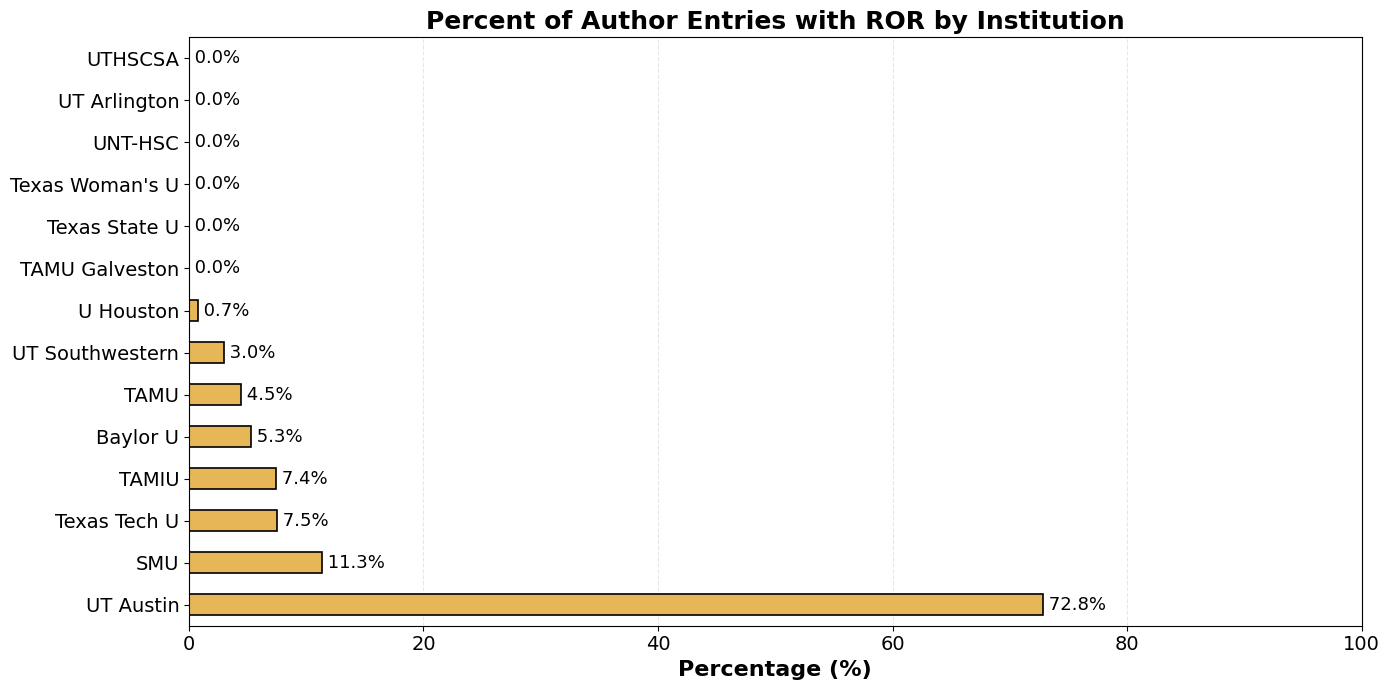

In [2]:
# Prepare the data
authors_plot = authors.copy()

# Convert 'missing_ror' to boolean (handle string values from CSV)
authors_plot['missing_ror'] = authors_plot['missing_ror'].astype(str).str.upper() == 'FALSE'

# Count TRUE values by institution
missing_by_institution = authors_plot[authors_plot['missing_ror']].groupby('institution_standardized').size()
total_by_institution = authors_plot.groupby('institution_standardized').size()

# Calculate percentage
missing_percent_by_institution = (missing_by_institution / total_by_institution * 100).fillna(0)
missing_percent_by_institution = missing_percent_by_institution.sort_values(ascending=False)

print(missing_percent_by_institution)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

for i, (idx, value) in enumerate(missing_percent_by_institution.items()):
    ax.text(value, i, f' {value:.1f}%', va='center', fontsize=13)

missing_percent_by_institution.plot(kind='barh', ax=ax, color="#E6B657", edgecolor='black', linewidth=1.2)
ax.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('', fontsize=12, fontweight='bold')
ax.set_title('Percent of Author Entries with ROR by Institution', fontsize=18, fontweight='bold')
ax.tick_params(labelsize=14)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

institution_standardized
UTHSCSA            25.000000
UT Southwestern     9.774436
UT Austin          59.547815
UT Arlington       42.105263
UNT-HSC            50.000000
U Houston          39.552239
Texas Woman's U    33.333333
Texas Tech U       47.222222
Texas State U      17.127072
TAMU Galveston     39.130435
TAMU               42.586399
TAMIU              24.074074
SMU                67.924528
Baylor U           38.244514
dtype: float64


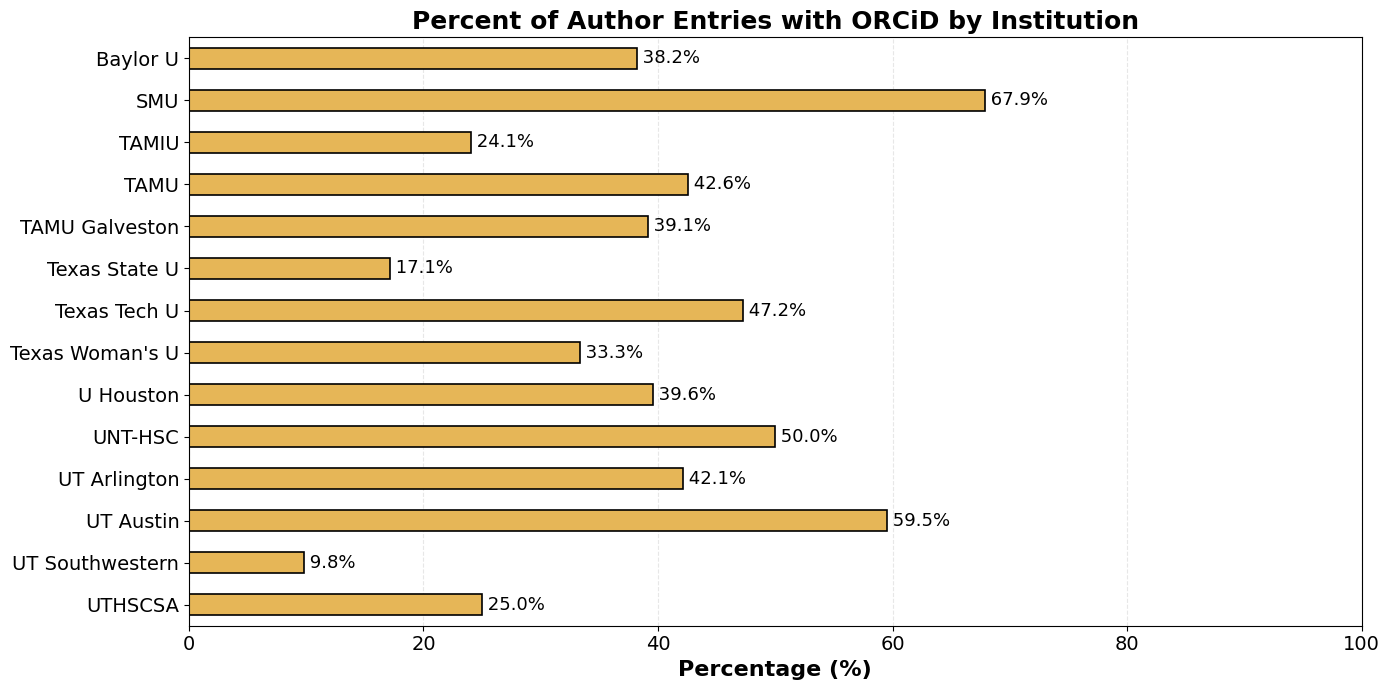

In [3]:
# Convert 'missing_ror' to boolean (handle string values from CSV)
authors_plot['missing_orcid'] = authors_plot['missing_orcid'].astype(str).str.upper() == 'FALSE'

# Count TRUE values by institution
missing_by_institution = authors_plot[authors_plot['missing_orcid']].groupby('institution_standardized').size()
total_by_institution = authors_plot.groupby('institution_standardized').size()

# Calculate percentage
missing_percent_by_institution = (missing_by_institution / total_by_institution * 100).fillna(0)
missing_percent_by_institution = missing_percent_by_institution.sort_index(ascending=False)

print(missing_percent_by_institution)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

for i, (idx, value) in enumerate(missing_percent_by_institution.items()):
    ax.text(value, i, f' {value:.1f}%', va='center', fontsize=13)

missing_percent_by_institution.plot(kind='barh', ax=ax, color="#E6B657", edgecolor='black', linewidth=1.2)
ax.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('', fontsize=12, fontweight='bold')
ax.set_title('Percent of Author Entries with ORCiD by Institution', fontsize=18, fontweight='bold')
ax.tick_params(labelsize=14)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

institution_standardized
UTHSCSA             0.000000
UT Southwestern     3.007519
UT Austin          72.807822
UT Arlington        0.000000
UNT-HSC             0.000000
U Houston           0.746269
Texas Woman's U     0.000000
Texas Tech U        7.539683
Texas State U       0.000000
TAMU Galveston      0.000000
TAMU                4.459309
TAMIU               7.407407
SMU                11.320755
Baylor U            5.329154
dtype: float64


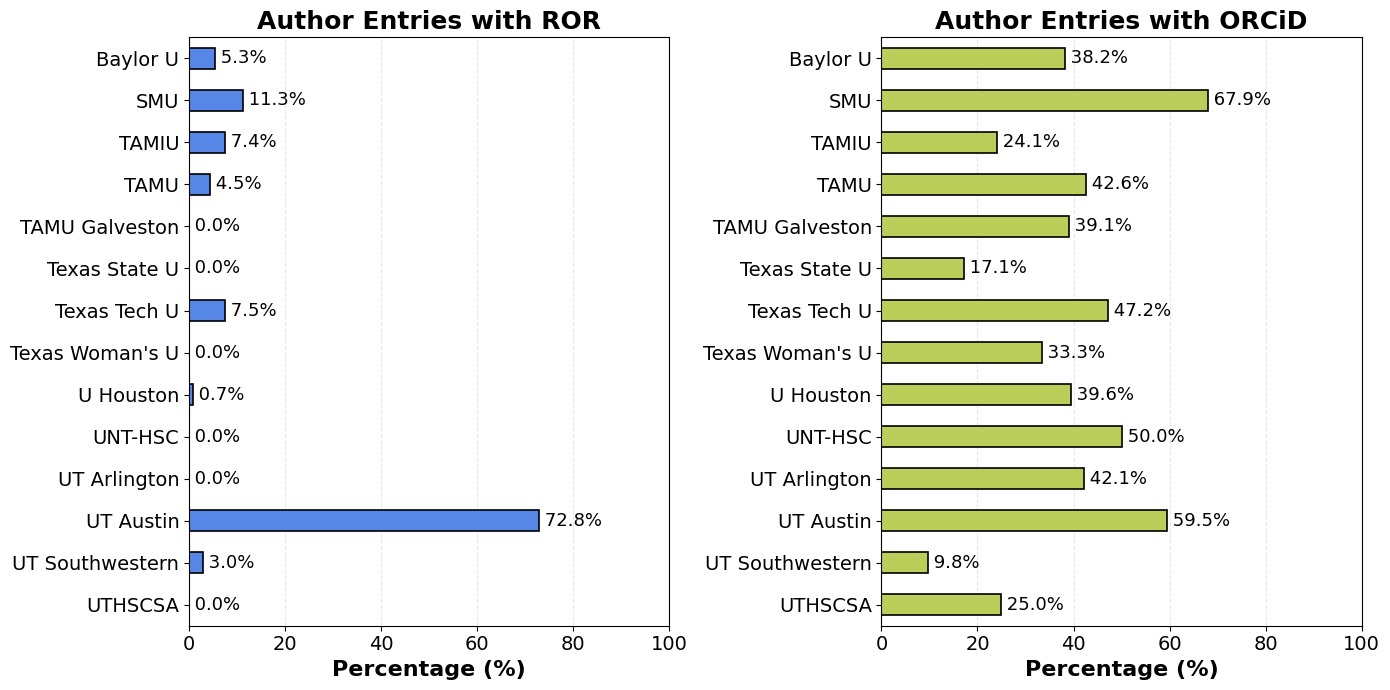

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Count TRUE values by institution
missing_by_institution = authors_plot[authors_plot['missing_ror']].groupby('institution_standardized').size()
total_by_institution = authors_plot.groupby('institution_standardized').size()

# Calculate percentage
missing_percent_by_institution = (missing_by_institution / total_by_institution * 100).fillna(0)
missing_percent_by_institution = missing_percent_by_institution.sort_index(ascending=False)

print(missing_percent_by_institution)

for i, (idx, value) in enumerate(missing_percent_by_institution.items()):
    ax1.text(value, i, f' {value:.1f}%', va='center', fontsize=13)

missing_percent_by_institution.plot(kind='barh', ax=ax1, color="#5787E6", edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax1.set_ylabel('', fontsize=12, fontweight='bold')
ax1.set_title('Author Entries with ROR', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=14)
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Count TRUE values by institution
missing_by_institution = authors_plot[authors_plot['missing_orcid']].groupby('institution_standardized').size()
total_by_institution = authors_plot.groupby('institution_standardized').size()

# Calculate percentage
missing_percent_by_institution = (missing_by_institution / total_by_institution * 100).fillna(0)
missing_percent_by_institution = missing_percent_by_institution.sort_index(ascending=False)

for i, (idx, value) in enumerate(missing_percent_by_institution.items()):
    ax2.text(value, i, f' {value:.1f}%', va='center', fontsize=13)

missing_percent_by_institution.plot(kind='barh', ax=ax2, color="#BACE59", edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax2.set_ylabel('', fontsize=12, fontweight='bold')
ax2.set_title('Author Entries with ORCiD', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=14)
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

                          Citations       URLs
institution_standardized                      
UTHSCSA                   43.750000  31.250000
UT Southwestern            6.722689   3.361345
UT Austin                 55.107188  54.476671
UT Arlington              60.000000  42.857143
UNT-HSC                   33.333333  33.333333
U Houston                 24.590164  14.754098
Texas Woman's U           33.333333  33.333333
Texas Tech U              32.624113  13.475177
Texas State U             14.084507   8.920188
TAMU Galveston             4.651163   4.651163
TAMU                      31.569966  10.068259
TAMIU                     15.909091   2.272727
SMU                       76.923077   0.000000
Baylor U                  51.655629  29.801325


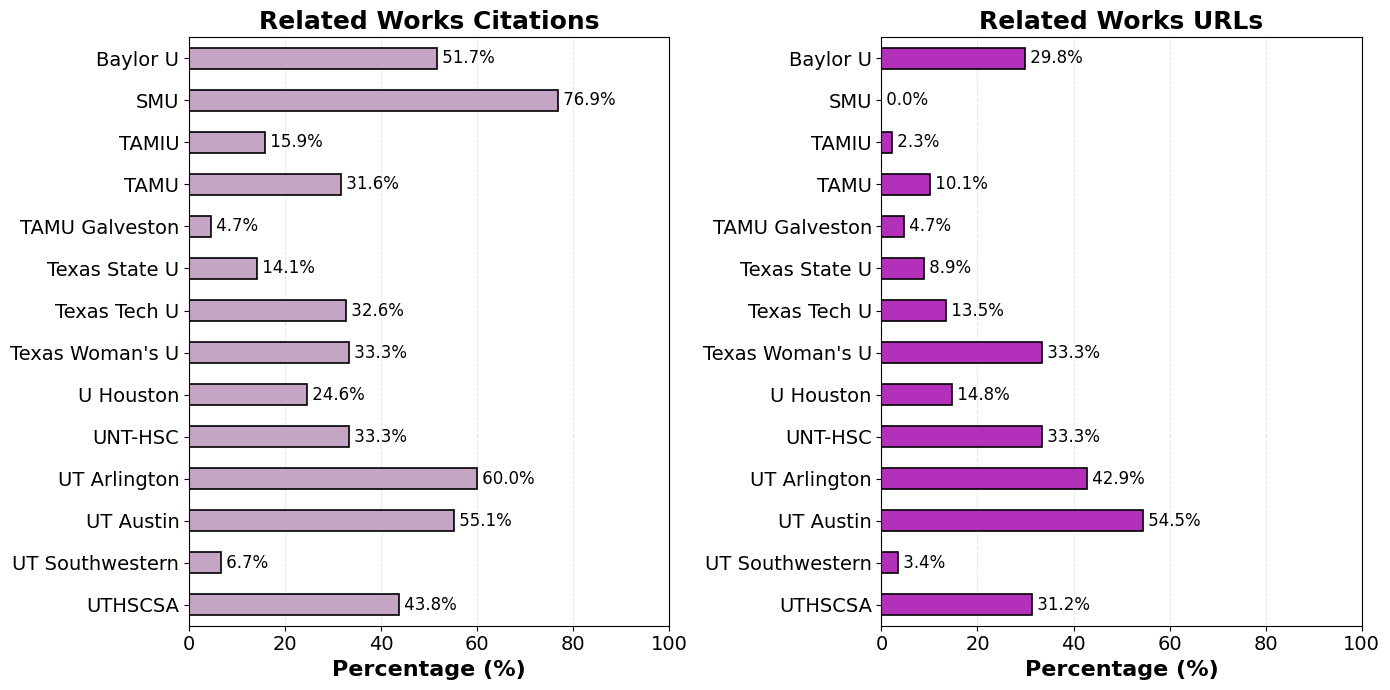

In [5]:
datasets_plot = datasets.copy()

# Count non-blank entries by institution
related_works_citations_by_institution = datasets_plot[datasets_plot['related_works_citations'].notna() & (datasets_plot['related_works_citations'] != '')].groupby('institution_standardized').size()
related_works_urls_by_institution = datasets_plot[datasets_plot['related_works_urls'].notna() & (datasets_plot['related_works_urls'] != '')].groupby('institution_standardized').size()

# Get total count by institution
total_by_institution = datasets_plot.groupby('institution_standardized').size()

# Calculate percentages
citations_percent = (related_works_citations_by_institution / total_by_institution * 100).fillna(0)
urls_percent = (related_works_urls_by_institution / total_by_institution * 100).fillna(0)

# Combine into a single dataframe for easier plotting
comparison_df = pd.DataFrame({
    'Citations': citations_percent,
    'URLs': urls_percent
}).fillna(0).sort_index(ascending=False)

print(comparison_df)

# Create the figure with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot Citations
citations_data = comparison_df['Citations']
citations_data.plot(kind='barh', ax=ax1, color="#C5A5C4", edgecolor='black', linewidth=1.2)
for i, (idx, value) in enumerate(citations_data.items()):
    ax1.text(value, i, f' {value:.1f}%', va='center', fontsize=12)
ax1.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax1.set_ylabel('', fontsize=12, fontweight='bold')
ax1.set_title('Related Works Citations', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=14)
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot URLs
urls_data = comparison_df['URLs']
urls_data.plot(kind='barh', ax=ax2, color="#B331BA", edgecolor='black', linewidth=1.2)
for i, (idx, value) in enumerate(urls_data.items()):
    ax2.text(value, i, f' {value:.1f}%', va='center', fontsize=12)
ax2.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax2.set_ylabel('', fontsize=12, fontweight='bold')
ax2.set_title('Related Works URLs', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=14)
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

institution_standardized
UTHSCSA             0.000000
UT Southwestern     0.000000
UT Austin          20.680958
UT Arlington        0.000000
UNT-HSC            50.000000
U Houston           4.918033
Texas Woman's U     0.000000
Texas Tech U        0.709220
Texas State U       1.408451
TAMU Galveston     23.255814
TAMU                3.754266
TAMIU               0.000000
SMU                 0.000000
Baylor U           19.205298
dtype: float64
institution_standardized
UTHSCSA            0.000000
UT Southwestern    0.000000
UT Austin          0.252207
UT Arlington       0.000000
UNT-HSC            0.000000
U Houston          0.000000
Texas Woman's U    0.000000
Texas Tech U       0.000000
Texas State U      0.000000
TAMU Galveston     0.000000
TAMU               0.000000
TAMIU              0.000000
SMU                0.000000
Baylor U           0.000000
dtype: float64


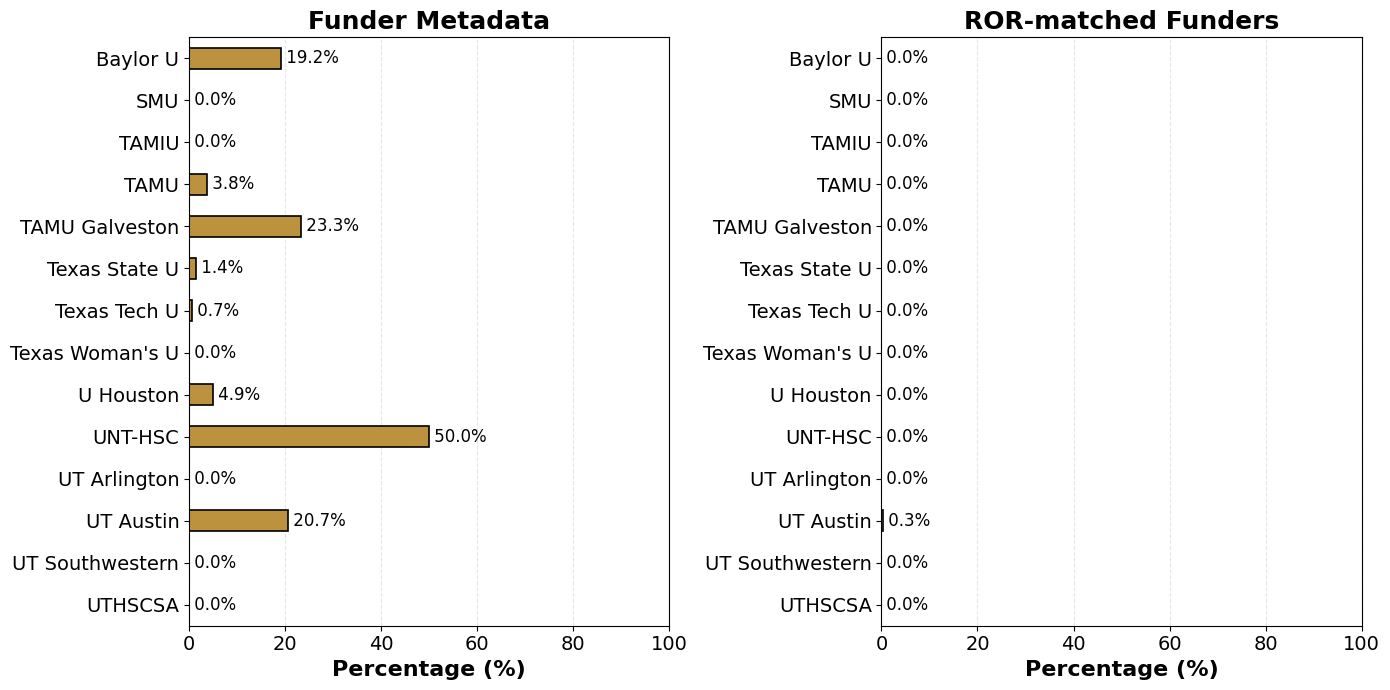

In [6]:
# Prepare the data
grants_plot = datasets.copy()

# Count non-blank entries by institution
non_blank_by_institution = grants_plot[grants_plot['grant_agencies'].notna() & (grants_plot['grant_agencies'] != '')].groupby('institution_standardized').size()
total_by_institution = grants_plot.groupby('institution_standardized').size()

# Count entries with 'ror.org' in grant_agencies by institution
ror_by_institution = grants_plot[grants_plot['grant_agencies'].notna() & (grants_plot['grant_agencies'].astype(str).str.contains('ror.org', na=False))].groupby('institution_standardized').size()

# Calculate percentages
grant_agencies_percent = (non_blank_by_institution / total_by_institution * 100).fillna(0)
ror_percent = (ror_by_institution / total_by_institution * 100).fillna(0)

# Sort by institution name descending
grant_agencies_percent = grant_agencies_percent.sort_index(ascending=False)
ror_percent = ror_percent.reindex(grant_agencies_percent.index).fillna(0)

print(grant_agencies_percent)
print(ror_percent)

# Create the figure with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot Grant Agencies Present
for i, (idx, value) in enumerate(grant_agencies_percent.items()):
    ax1.text(value, i, f' {value:.1f}%', va='center', fontsize=12)
grant_agencies_percent.plot(kind='barh', ax=ax1, color="#BC923E", edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax1.set_ylabel('', fontsize=12, fontweight='bold')
ax1.set_title('Funder Metadata', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=14)
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot ROR.org Present
for i, (idx, value) in enumerate(ror_percent.items()):
    ax2.text(value, i, f' {value:.1f}%', va='center', fontsize=12)
ror_percent.plot(kind='barh', ax=ax2, color="#7CB9E8", edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Percentage (%)', fontsize=16, fontweight='bold')
ax2.set_ylabel('', fontsize=12, fontweight='bold')
ax2.set_title('ROR-matched Funders', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=14)
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()